In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_digits, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# K-Nearest Neighbors (KNN) Notebook

This notebook demonstrates a professional KNN workflow across three real-world examples:

1. **Breast cancer classification** — binary classification for tumor diagnosis.
2. **Handwritten digit recognition (OCR)** — multiclass classification used in postal sorting and check processing.
3. **Diabetes progression prediction** — KNN regression for a medical regression use case.

Each section includes a clear problem description, model implementation, data preparation, evaluation metrics, and detailed visualizations.

## KNN Overview and Utility Functions

This cell defines the core KNN logic and helper functions used throughout the notebook. It includes classification and regression prediction functions, distance measurement, and reusable plotting utilities.

In [17]:
np.random.seed(42)

def euclidean_distance(point1: np.ndarray, point2: np.ndarray) -> float:
    """Compute Euclidean distance between two feature vectors."""
    return np.sqrt(np.sum((point1 - point2) ** 2))


def get_neighbors(X_train: np.ndarray, y_train: np.ndarray, x_test: np.ndarray, k: int):
    """Return labels or values of the k nearest neighbors for a single test point."""
    distances = np.linalg.norm(X_train - x_test, axis=1)
    neighbor_indices = np.argsort(distances)[:k]
    return y_train[neighbor_indices]


def knn_predict(X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, k: int) -> np.ndarray:
    """Predict class labels for the test set using KNN classification."""
    predictions = []
    for x_test in X_test:
        neighbor_labels = get_neighbors(X_train, y_train, x_test, k)
        values, counts = np.unique(neighbor_labels, return_counts=True)
        predictions.append(values[np.argmax(counts)])
    return np.array(predictions)


def knn_predict_regression(X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, k: int) -> np.ndarray:
    """Predict continuous values for the test set using KNN regression."""
    predictions = []
    for x_test in X_test:
        neighbor_values = get_neighbors(X_train, y_train, x_test, k)
        predictions.append(np.mean(neighbor_values))
    return np.array(predictions)


def plot_confusion_matrix(cm: np.ndarray, class_names: list, title: str):
    """Display a confusion matrix heatmap."""
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues', interpolation='nearest')
    plt.title(title)
    plt.colorbar(fraction=0.046, pad=0.04)
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
    plt.tight_layout()
    plt.show()


def plot_roc(y_true: np.ndarray, y_scores: np.ndarray, title: str):
    """Plot ROC curve for binary classification."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='darkorange')
    plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
    plt.title(title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


def plot_actual_vs_predicted(y_true: np.ndarray, y_pred: np.ndarray, title: str):
    """Plot actual vs predicted values for regression."""
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2)
    plt.title(title)
    plt.xlabel('Actual values')
    plt.ylabel('Predicted values')
    plt.grid(True)
    plt.show()


def plot_residuals(y_true: np.ndarray, y_pred: np.ndarray, title: str):
    """Plot the distribution of residuals for regression."""
    residuals = y_true - y_pred
    plt.figure(figsize=(7, 5))
    plt.hist(residuals, bins=25, edgecolor='k', alpha=0.7)
    plt.title(title)
    plt.xlabel('Residual')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

## Example 1: Breast Cancer Classification

This section solves a binary classification problem using the breast cancer dataset. The objective is to classify tumors as **malignant** or **benign** using KNN.

The workflow includes:
- dataset loading
- feature scaling
- KNN classification
- model evaluation using accuracy, precision, recall, F1 score, confusion matrix, and ROC AUC
- visual inspection of key features

In [18]:
# Load the breast cancer dataset and prepare the training and test sets.
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and predict with KNN.
k = 5
y_pred = knn_predict(X_train_scaled, y_train, X_test_scaled, k=k)

Breast cancer classification accuracy (k=5): 0.9790

Classification report:
              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        53
      benign       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



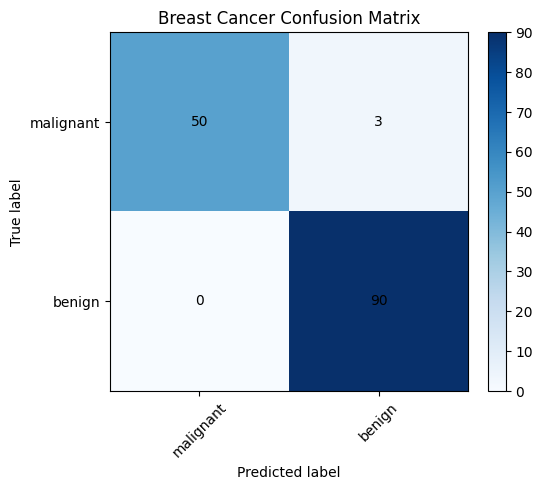

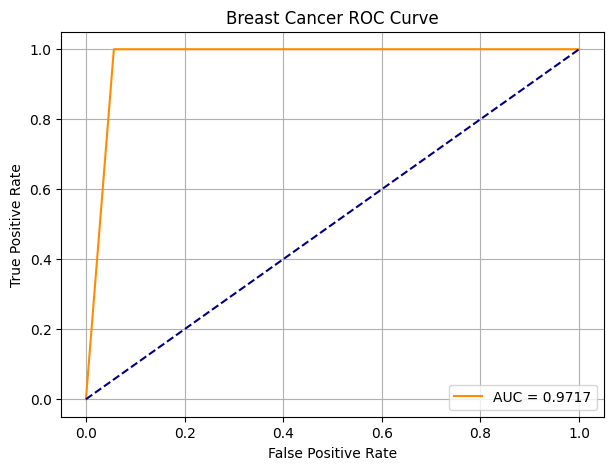

In [19]:
# Evaluate classification performance for the breast cancer example.
accuracy = accuracy_score(y_test, y_pred)
print(f'Breast cancer classification accuracy (k={k}): {accuracy:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, data.target_names.tolist(), 'Breast Cancer Confusion Matrix')
plot_roc(y_test, y_pred, 'Breast Cancer ROC Curve')

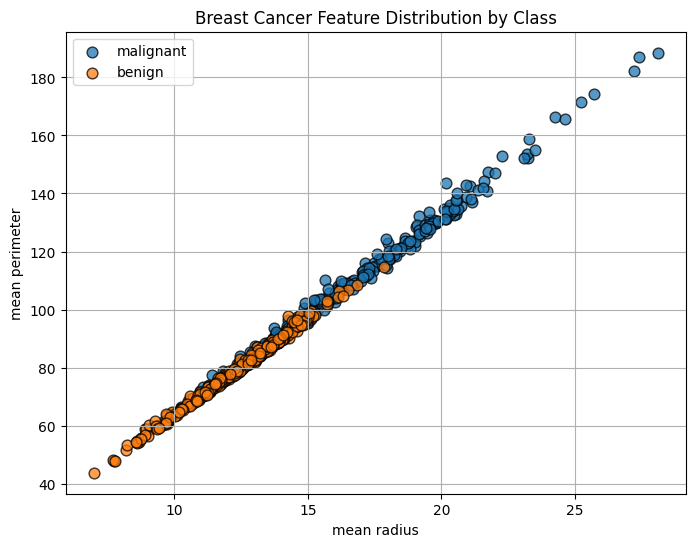

In [20]:
# Visualize two selected features with class labels for breast cancer.
selected_features = (0, 2)  # mean radius and mean perimeter
X_selected = X[:, selected_features]

plt.figure(figsize=(8, 6))
for class_value in np.unique(y):
    mask = y == class_value
    plt.scatter(
        X_selected[mask, 0],
        X_selected[mask, 1],
        alpha=0.75,
        edgecolor='k',
        s=60,
        label=data.target_names[class_value],
    )
plt.xlabel(feature_names[selected_features[0]])
plt.ylabel(feature_names[selected_features[1]])
plt.title('Breast Cancer Feature Distribution by Class')
plt.legend()
plt.grid(True)
plt.show()

## Example 2: Handwritten Digit Recognition (OCR)

This section demonstrates KNN for multiclass classification on the digits dataset. It is a real-world example relevant to postal automation, banking, and mobile input recognition.

The workflow includes:
- dataset loading
- feature scaling
- KNN multiclass classification
- evaluation using accuracy, classification report, and confusion matrix
- visualization of sample digit predictions

In [21]:
# Load the digits dataset and prepare the training and test sets.

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits,
    y_digits,
    test_size=0.25,
    random_state=42,
    stratify=y_digits,
)

scaler_digits = StandardScaler()
X_train_d_scaled = scaler_digits.fit_transform(X_train_d)
X_test_d_scaled = scaler_digits.transform(X_test_d)

# Train and predict with KNN.
k_digits = 5
y_pred_d = knn_predict(X_train_d_scaled, y_train_d, X_test_d_scaled, k=k_digits)

Digits recognition accuracy (k=5): 0.9644

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.94      1.00      0.97        46
           2       0.96      1.00      0.98        44
           3       0.98      0.98      0.98        46
           4       0.98      0.93      0.95        45
           5       0.98      0.96      0.97        46
           6       0.98      0.98      0.98        45
           7       0.92      0.98      0.95        45
           8       0.97      0.91      0.94        43
           9       0.95      0.91      0.93        45

    accuracy                           0.96       450
   macro avg       0.97      0.96      0.96       450
weighted avg       0.97      0.96      0.96       450



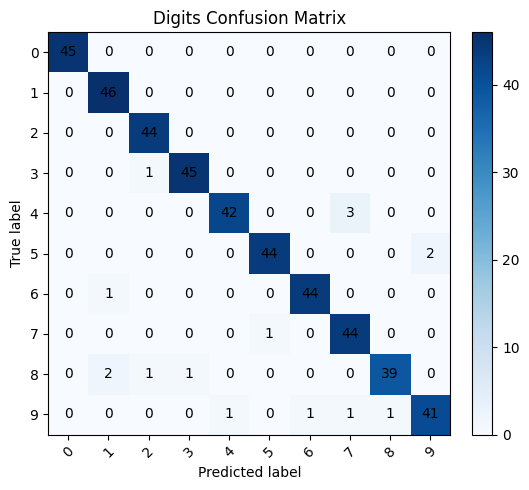

In [22]:
# Evaluate the handwritten digit recognition model.
accuracy_digits = accuracy_score(y_test_d, y_pred_d)
print(f'Digits recognition accuracy (k={k_digits}): {accuracy_digits:.4f}')
print('\nClassification report:')
print(classification_report(y_test_d, y_pred_d, target_names=[str(i) for i in digits.target_names]))

cm_digits = confusion_matrix(y_test_d, y_pred_d)
plot_confusion_matrix(cm_digits, [str(i) for i in digits.target_names], 'Digits Confusion Matrix')

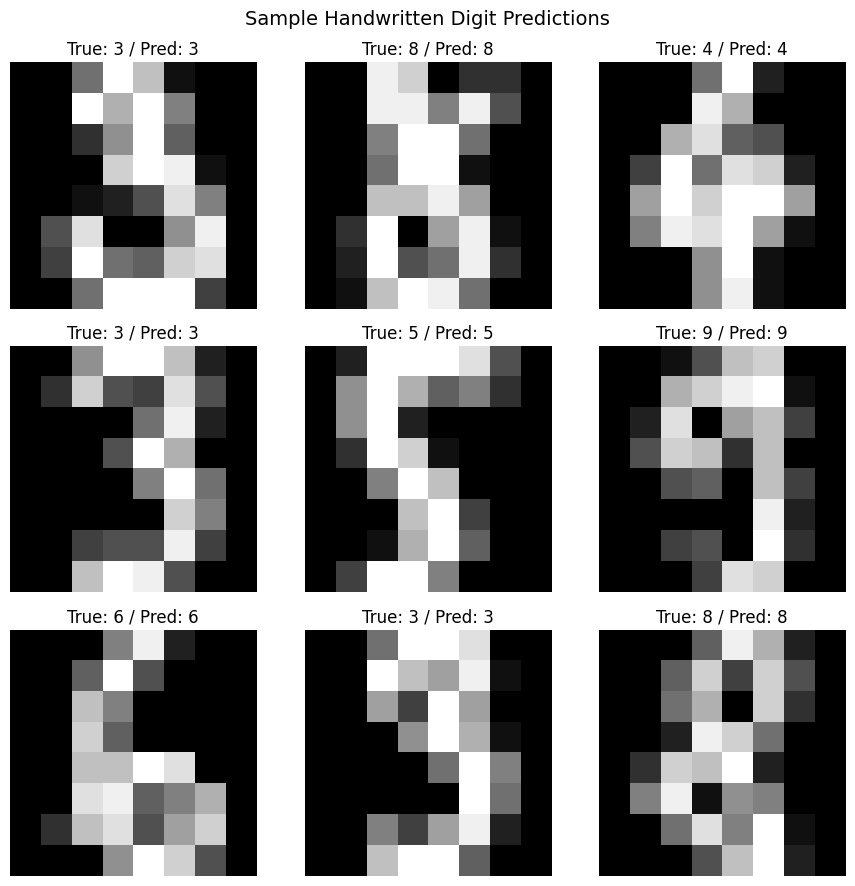

In [23]:
# Display sample digit prediction results.
indices = np.random.choice(len(X_test_d), size=9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X_test_d[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f'True: {y_test_d[idx]} / Pred: {y_pred_d[idx]}')
    ax.axis('off')
plt.suptitle('Sample Handwritten Digit Predictions', fontsize=14)
plt.tight_layout()
plt.show()

## Example 3: Diabetes Progression Regression

This section uses KNN regression to model a continuous target. The diabetes dataset is a standard medical regression benchmark that measures disease progression based on clinical inputs.

The workflow includes:
- dataset loading
- feature scaling
- KNN regression using average neighbor values
- evaluation using MSE, RMSE, MAE, and R²
- regression-specific visualizations including prediction scatter and residuals

In [24]:
# Load the diabetes dataset and prepare the training and test sets.

diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42,
)

scaler_reg = StandardScaler()
X_train_r_scaled = scaler_reg.fit_transform(X_train_r)
X_test_r_scaled = scaler_reg.transform(X_test_r)

# Train and predict with KNN regression.
k_reg = 5
y_pred_r = knn_predict_regression(X_train_r_scaled, y_train_r, X_test_r_scaled, k=k_reg)

Diabetes progression regression metrics:
MSE:  3144.958
RMSE: 56.080
MAE:  43.016
R²:   0.431


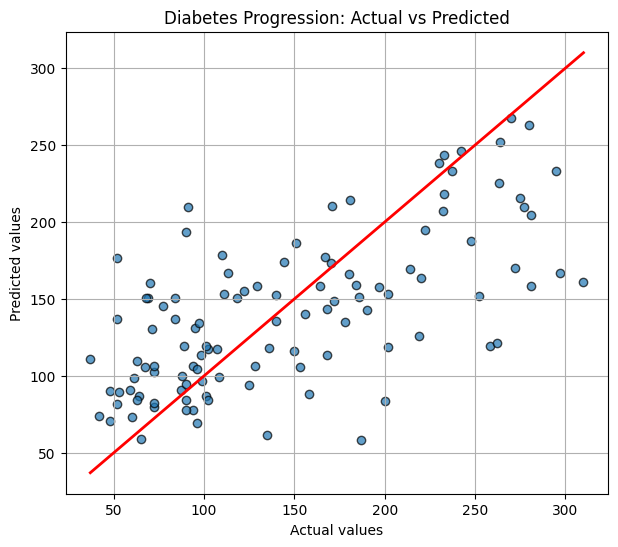

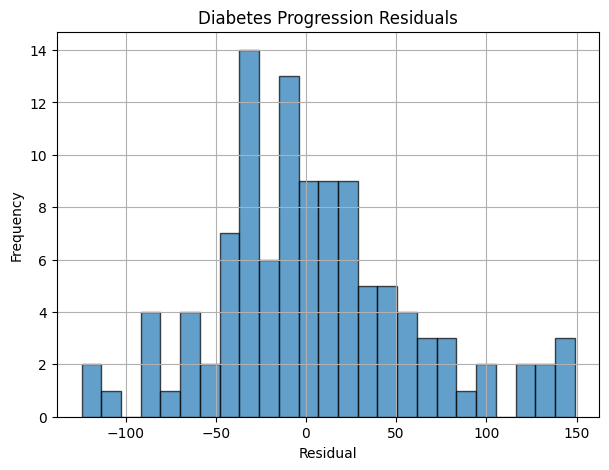

In [25]:
# Evaluate the KNN regression model on diabetes progression.
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print('Diabetes progression regression metrics:')
print(f'MSE:  {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAE:  {mae:.3f}')
print(f'R²:   {r2:.3f}')

plot_actual_vs_predicted(y_test_r, y_pred_r, 'Diabetes Progression: Actual vs Predicted')
plot_residuals(y_test_r, y_pred_r, 'Diabetes Progression Residuals')

## Summary

This notebook provided three professional KNN examples:
- breast cancer classification with binary metrics and ROC analysis
- handwritten digit recognition with multiclass classification metrics and sample predictions
- diabetes progression regression with error metrics and residual analysis

These examples demonstrate how to structure a KNN workflow, evaluate results, and visualize performance in real-world applications.